# MA(q) Parameter Estimation

The moving average model of order $q$, denoted by $\text{MA}(q)$, is defined by,

$
\begin{align}
X_t = \sum_{i=1}^q \vartheta_i \varepsilon_{t-i} + \varepsilon_t
\end{align}
\tag{1}
$

where $\varepsilon_t$ are independent and identically distributed random variables with distribution,

$
\begin{align}
\varepsilon_i \sim \text{Normal}(0, \sigma)
\end{align}
\tag{2}
$

It follows that,

$
\begin{align}
&\text{E}[\varepsilon_t] = 0 \\
&\text{E}[\varepsilon_t^2] = \sigma^2 \\
&\text{E}[\varepsilon_t \varepsilon_s] = \delta_{ts} \sigma^2
\end{align}
\tag{3}
$

Here the $\vartheta_i$ are estimated given an $MA(q)$ time series. 

## Includes

In [1]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import arima
from lib.plots import stack, fpoints, fcurve
from lib.utils import create_parameter_scan

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [2]:
nsample = 1000

def comparison_plot(θ_vals, title, ylim, *params):
    labels = [f"θ={val}" for val in θ_vals] 
    ylabels = r"$S_t$"
    source = lambda **kwargs : arima.create_ma_source(**kwargs)
    t, scan = create_parameter_scan(source, *params)
    stack(scan, t, ylim=ylim, title=title, labels=labels, ylabels=ylabels, xlabel="Time", figsize=(10, 6), lw=1)
    return t, scan

## Simulations ($\sigma = 1$)

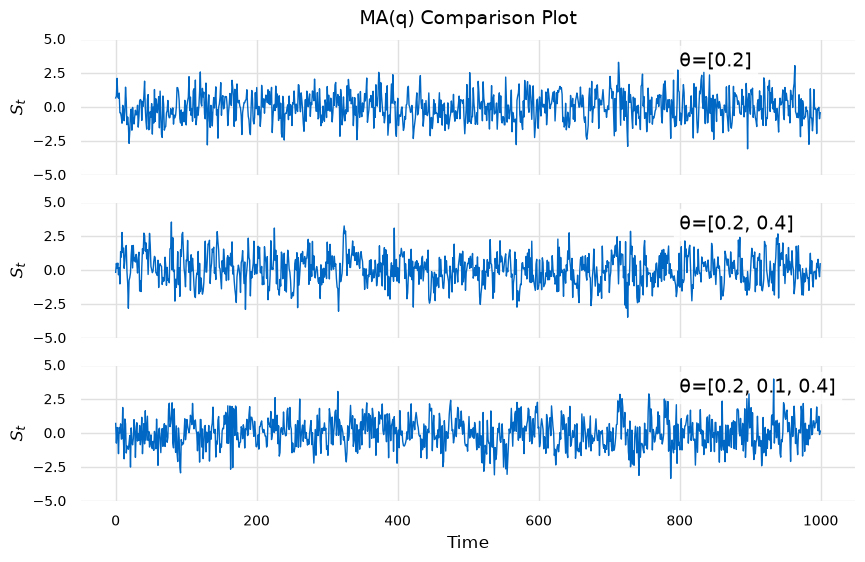

In [3]:
nsample = 1000
σ = 1.0
θ_vals = [[0.2], [0.2, 0.4], [0.2, 0.1, 0.4]]
params = [{"θ": θ, "σ": σ, "npts": nsample} for θ in θ_vals]
title = "MA(q) Comparison Plot"
t, scan = comparison_plot(θ_vals, title, (-5.0, 5.0), *params)

## Estimation of $\text{MA}(q)$ Parameters

$\text{MA}(q)$ parameters are estimated using `statsmodels.tsa.arima_model.ARMA`

### $\text{MA}(1)$ Example ($\varphi = 0.2$)

In [4]:
result, result_model = arima.compute_ma_estimate(scan[0], order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(0, 0, 1)   Log Likelihood               -1422.400
Date:                Sun, 23 Aug 2026   AIC                           2850.800
Time:                        14:21:26   BIC                           2865.523
Sample:                             0   HQIC                          2856.396
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0167      0.038     -0.434      0.664      -0.092       0.059
ma.L1          0.2096      0.031      6.822      0.000       0.149       0.270
sigma2         1.0069      0.047     21.362      0.000       0.915       1.099
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):                 1.80
Prob(Q):                              0.86   Prob(JB):                         0.41
Heteroskedasticity (H):               1.23   Skew:                             0.06
Prob(H) (two-sided):                  0.06   Kurtosis:                         2.83
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [5]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "MA",
   "const": {
      "est": -0.016698363779343948,
      "err": 0.03846341272723483,
      "est_label": "$\\hat{\\mu^*}$",
      "err_label": "$\\sigma_{\\hat{\\mu^*}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "13aa6bd4-946a-43c7-9031-b77518bd5cb3",
      "param_type": "ARMA_CONST"
   },
   "order": 1,
   "params": [
      {
         "est": 0.20957394787573835,
         "err": 0.030719500950834474,
         "est_label": "$\\hat{\\theta_{0}}$",
         "err_label": "$\\sigma_{$\\hat{\\theta_{0}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "13aa6bd4-946a-43c7-9031-b77518bd5cb3",
         "param_type": "ARMA_PARAM"
      }
   ],
   "sigma2": {
      "est": 1.0068914343146156,
      "err": 0.04713472850933655,
      "est_label": "$\\hat{\\sigma^2}$",
      "err_label": "$\\sigma_{\\hat{\\sigma^2}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": 

### $\text{MA}(2)$ Example ($\varphi = [0.2, 0.4]$)

In [6]:
result, result_model = arima.compute_ma_estimate(scan[1], order=2)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(0, 0, 2)   Log Likelihood               -1436.902
Date:                Sun, 23 Aug 2026   AIC                           2881.805
Time:                        14:21:26   BIC                           2901.436
Sample:                             0   HQIC                          2889.266
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0536      0.053      1.018      0.309      -0.050       0.157
ma.L1          0.2324      0.029      8.132      0.000       0.176       0.288
ma.L2          0.3994      0.029     13.586      0.000       0.342       0.457
sigma2         1.0362      0.049     21.232      0.000       0.941       1.132
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 1.66
Prob(Q):                              0.97   Prob(JB):                         0.44
Heteroskedasticity (H):               0.93   Skew:                             0.04
Prob(H) (two-sided):                  0.49   Kurtosis:                         2.81
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [7]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "MA",
   "const": {
      "est": 0.053564940647503737,
      "err": 0.05259908683090217,
      "est_label": "$\\hat{\\mu^*}$",
      "err_label": "$\\sigma_{\\hat{\\mu^*}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "5c9b9c02-7237-4616-aad0-a06e3b4df44e",
      "param_type": "ARMA_CONST"
   },
   "order": 2,
   "params": [
      {
         "est": 0.2324217396998834,
         "err": 0.02858078718587363,
         "est_label": "$\\hat{\\theta_{0}}$",
         "err_label": "$\\sigma_{$\\hat{\\theta_{0}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "5c9b9c02-7237-4616-aad0-a06e3b4df44e",
         "param_type": "ARMA_PARAM"
      },
      {
         "est": 0.39935329771701844,
         "err": 0.029395533129609144,
         "est_label": "$\\hat{\\theta_{1}}$",
         "err_label": "$\\sigma_{$\\hat{\\theta_{1}}}$",
         "row": 0,
         "column": 0,
         "order": 2,
   

### $\text{MA}(3)$ Example ($\varphi = [0.2, 0.1, 0.4]$)

In [8]:
result, result_model = arima.compute_ma_estimate(scan[2], order=3)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(0, 0, 3)   Log Likelihood               -1399.662
Date:                Sun, 23 Aug 2026   AIC                           2809.323
Time:                        14:21:26   BIC                           2833.862
Sample:                             0   HQIC                          2818.650
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0358      0.054      0.663      0.507      -0.070       0.141
ma.L1          0.1756      0.029      6.084      0.000       0.119       0.232
ma.L2          0.1037      0.028      3.722      0.000       0.049       0.158
ma.L3          0.4546      0.028     16.176      0.000       0.400       0.510
sigma2         0.9615      0.045     21.398      0.000       0.873       1.050
===================================================================================
Ljung-Box (L1) (Q):                   0.10   Jarque-Bera (JB):                 0.81
Prob(Q):                              0.75   Prob(JB):                         0.67
Heteroskedasticity (H):               1.17   Skew:                             0.02
Prob(H) (two-sided):                  0.16   Kurtosis:                         2.87
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [9]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "MA",
   "const": {
      "est": 0.03575834395002288,
      "err": 0.05395054613301803,
      "est_label": "$\\hat{\\mu^*}$",
      "err_label": "$\\sigma_{\\hat{\\mu^*}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "db7604de-5868-4a95-8fa8-bbd4202ae981",
      "param_type": "ARMA_CONST"
   },
   "order": 3,
   "params": [
      {
         "est": 0.17559098605839407,
         "err": 0.028861262804451508,
         "est_label": "$\\hat{\\theta_{0}}$",
         "err_label": "$\\sigma_{$\\hat{\\theta_{0}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "db7604de-5868-4a95-8fa8-bbd4202ae981",
         "param_type": "ARMA_PARAM"
      },
      {
         "est": 0.10369379751048825,
         "err": 0.02785771496611882,
         "est_label": "$\\hat{\\theta_{1}}$",
         "err_label": "$\\sigma_{$\\hat{\\theta_{1}}}$",
         "row": 0,
         "column": 0,
         "order": 2,
   

## Simulations ($\sigma = 5$)

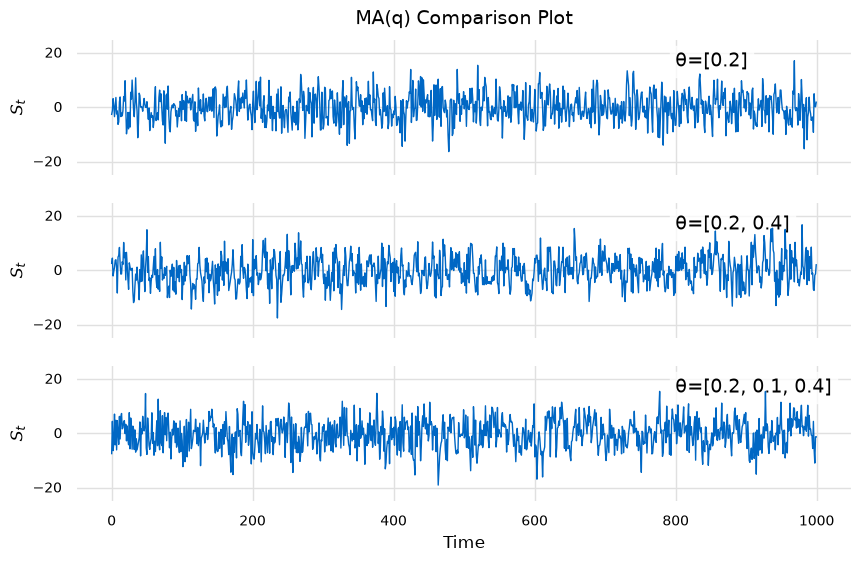

In [10]:
nsample = 1000
σ = 5.0
θ_vals = [[0.2], [0.2, 0.4], [0.2, 0.1, 0.4]]
params = [{"θ": θ, "σ": σ, "npts": nsample} for θ in θ_vals]
title = "MA(q) Comparison Plot"
t, scan = comparison_plot(θ_vals, title, (-25.0, 25.0), *params)

## Estimation of $\text{MA}(q)$ Parameters

$\text{MA}(q)$ parameters are estimated using `statsmodels.tsa.arima_model.ARMA`

### $\text{MA}(1)$ Example ($\varphi = 0.2$)

In [11]:
result, result_model = arima.compute_ma_estimate(scan[0], order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(0, 0, 1)   Log Likelihood               -3041.161
Date:                Sun, 23 Aug 2026   AIC                           6088.322
Time:                        14:21:26   BIC                           6103.046
Sample:                             0   HQIC                          6093.918
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0661      0.194     -0.341      0.733      -0.447       0.314
ma.L1          0.2124      0.032      6.556      0.000       0.149       0.276
sigma2        25.6462      1.153     22.251      0.000      23.387      27.905
===================================================================================
Ljung-Box (L1) (Q):                   0.05   Jarque-Bera (JB):                 0.17
Prob(Q):                              0.83   Prob(JB):                         0.92
Heteroskedasticity (H):               1.10   Skew:                             0.03
Prob(H) (two-sided):                  0.39   Kurtosis:                         2.98
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [12]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "MA",
   "const": {
      "est": -0.06612696946363338,
      "err": 0.1941943420745798,
      "est_label": "$\\hat{\\mu^*}$",
      "err_label": "$\\sigma_{\\hat{\\mu^*}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "fa1f49d4-d781-4d8d-9489-32398ea54ef8",
      "param_type": "ARMA_CONST"
   },
   "order": 1,
   "params": [
      {
         "est": 0.21239158080592999,
         "err": 0.03239540692441111,
         "est_label": "$\\hat{\\theta_{0}}$",
         "err_label": "$\\sigma_{$\\hat{\\theta_{0}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "fa1f49d4-d781-4d8d-9489-32398ea54ef8",
         "param_type": "ARMA_PARAM"
      }
   ],
   "sigma2": {
      "est": 25.64624076226743,
      "err": 1.1525763820854336,
      "est_label": "$\\hat{\\sigma^2}$",
      "err_label": "$\\sigma_{\\hat{\\sigma^2}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "fa1f

### $\text{MA}(2)$ Example ($\varphi = [0.2, 0.4]$)

In [13]:
result, result_model = arima.compute_ma_estimate(scan[1], order=2)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(0, 0, 2)   Log Likelihood               -3000.108
Date:                Sun, 23 Aug 2026   AIC                           6008.217
Time:                        14:21:26   BIC                           6027.848
Sample:                             0   HQIC                          6015.678
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1431      0.256     -0.560      0.576      -0.644       0.358
ma.L1          0.2460      0.029      8.464      0.000       0.189       0.303
ma.L2          0.4146      0.028     14.638      0.000       0.359       0.470
sigma2        23.6157      1.053     22.418      0.000      21.551      25.680
===================================================================================
Ljung-Box (L1) (Q):                   0.06   Jarque-Bera (JB):                 0.89
Prob(Q):                              0.80   Prob(JB):                         0.64
Heteroskedasticity (H):               0.92   Skew:                             0.07
Prob(H) (two-sided):                  0.46   Kurtosis:                         3.02
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [14]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "MA",
   "const": {
      "est": -0.14314880097883625,
      "err": 0.2557004777447886,
      "est_label": "$\\hat{\\mu^*}$",
      "err_label": "$\\sigma_{\\hat{\\mu^*}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "a27cd1a2-16f0-429e-ae47-e15e707a9274",
      "param_type": "ARMA_CONST"
   },
   "order": 2,
   "params": [
      {
         "est": 0.24595490079729707,
         "err": 0.02905750561815798,
         "est_label": "$\\hat{\\theta_{0}}$",
         "err_label": "$\\sigma_{$\\hat{\\theta_{0}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "a27cd1a2-16f0-429e-ae47-e15e707a9274",
         "param_type": "ARMA_PARAM"
      },
      {
         "est": 0.41456599409037764,
         "err": 0.028321007762724348,
         "est_label": "$\\hat{\\theta_{1}}$",
         "err_label": "$\\sigma_{$\\hat{\\theta_{1}}}$",
         "row": 0,
         "column": 0,
         "order": 2,
   

### $\text{MA}(3)$ Example ($\varphi = [0.2, 0.1, 0.4]$)

In [15]:
result, result_model = arima.compute_ma_estimate(scan[2], order=3)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(0, 0, 3)   Log Likelihood               -3025.457
Date:                Sun, 23 Aug 2026   AIC                           6060.913
Time:                        14:21:26   BIC                           6085.452
Sample:                             0   HQIC                          6070.240
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.2588      0.266     -0.975      0.330      -0.779       0.262
ma.L1          0.2044      0.029      6.928      0.000       0.147       0.262
ma.L2          0.1155      0.030      3.820      0.000       0.056       0.175
ma.L3          0.3587      0.029     12.464      0.000       0.302       0.415
sigma2        24.8432      1.172     21.194      0.000      22.546      27.141
===================================================================================
Ljung-Box (L1) (Q):                   0.05   Jarque-Bera (JB):                 2.66
Prob(Q):                              0.83   Prob(JB):                         0.27
Heteroskedasticity (H):               0.84   Skew:                            -0.08
Prob(H) (two-sided):                  0.12   Kurtosis:                         2.81
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [16]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "MA",
   "const": {
      "est": -0.2587663134160713,
      "err": 0.26552116899340866,
      "est_label": "$\\hat{\\mu^*}$",
      "err_label": "$\\sigma_{\\hat{\\mu^*}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "aca365ad-107a-411c-ba29-bfee7b2e2fa7",
      "param_type": "ARMA_CONST"
   },
   "order": 3,
   "params": [
      {
         "est": 0.20436998179691027,
         "err": 0.029497549125918905,
         "est_label": "$\\hat{\\theta_{0}}$",
         "err_label": "$\\sigma_{$\\hat{\\theta_{0}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "aca365ad-107a-411c-ba29-bfee7b2e2fa7",
         "param_type": "ARMA_PARAM"
      },
      {
         "est": 0.11552103557322554,
         "err": 0.03024374869983528,
         "est_label": "$\\hat{\\theta_{1}}$",
         "err_label": "$\\sigma_{$\\hat{\\theta_{1}}}$",
         "row": 0,
         "column": 0,
         "order": 2,
   